# Small Language Model — Colab Training Notebook

Trains a small Transformer using your **custom HybridTokenizer**.

**Prerequisites:**
1. Run `train_tokenizer.ipynb` first and download `tokenizer.pkl.gz`
2. Upload `tokenizer.pkl.gz` to `/content/` before running this notebook

**Colab secrets:** add `HF_TOKEN` in the left-sidebar lock icon (optional for public datasets).

In [1]:
%pip install -q "git+https://github.com/sh20022002/small-Language-Model.git@main"
%pip install -q datasets transformers

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os

hf_token = None
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
except Exception:
    hf_token = os.environ.get('HF_TOKEN')

if hf_token:
    from huggingface_hub import login
    login(token=hf_token, add_to_git_credential=False)
    print('Logged in to HuggingFace')
else:
    print('No HF_TOKEN — public datasets work without login')

Logged in to HuggingFace


In [3]:
import os
import torch
import torch.nn.functional as F
from functools import partial
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from transformers import AutoTokenizer

from my_slm.transformer import Transformer
from my_slm.train import train_model, get_cosine_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB


In [4]:
from google.colab import drive
drive.mount('/content/drive')

CKPT_DIR = '/content/drive/MyDrive/slm_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
print(f'Checkpoints → {CKPT_DIR}')

Mounted at /content/drive
Checkpoints → /content/drive/MyDrive/slm_checkpoints


In [5]:
MAX_LEN = 8192 # Define maximum sequence length here. This will be used by the tokenizer and dataset classes.

## Load the HybridTokenizer

Upload `tokenizer.pkl.gz` (produced by `train_tokenizer.ipynb`) to `/content/` first.

In [ ]:
from transformers import AutoTokenizer

# GPT-2 tokenizer: BPE with spaces embedded in tokens ("Ġthe" = " the").
# No ##-continuation tokens → no word-boundary ambiguity during causal generation.
# BERT's WordPiece (## prefixes) is designed for masked LM, not next-token prediction,
# and causes merged-word artifacts like "whoii", "tantan", "worldrere" in output.
HF_MODEL_NAME = 'gpt2'
tok = AutoTokenizer.from_pretrained(HF_MODEL_NAME)

# GPT-2 has no pad token by default — use EOS as pad (common practice)
tok.pad_token = tok.eos_token

pad_id     = tok.pad_token_id
eos_id     = tok.eos_token_id
vocab_size = tok.vocab_size  # 50,257

print(f'Tokenizer  : {HF_MODEL_NAME}')
print(f'Vocab size : {vocab_size:,}')
print(f'PAD id     : {pad_id}')
print(f'EOS id     : {eos_id}')

test_ids = tok.encode('Hello, world! This is a test sentence.')
print(f'Test encode: {test_ids}')
print(f'Test decode: {repr(tok.decode(test_ids))}')

In [7]:
class TextDataset(Dataset):
    """Encodes plain text using a Hugging Face Tokenizer and returns a flat token tensor."""
    def __init__(self, data, tok, max_length=256, text_key='text'):
        self.data       = data
        self.tok        = tok
        self.max_length = max_length
        self.text_key   = text_key

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx].get(self.text_key, '') or ''
        # Use HF tokenizer's encode method directly, handle truncation
        encoded_input = self.tok(
            text,
            max_length=self.max_length,
            truncation=True,
            return_attention_mask=False, # Attention mask will be created in collate_fn
            return_token_type_ids=False,
            add_special_tokens=True
        )
        ids = encoded_input['input_ids']
        return torch.tensor(ids, dtype=torch.long)


class InstructDataset(Dataset):
    """Alpaca-format instruction dataset using a Hugging Face Tokenizer."""
    def __init__(self, data, tok, max_length=256):
        self.data       = data
        self.tok        = tok
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        inp  = item.get('input', '') or ''
        text = (
            f"### Instruction:\n{item['instruction']}\n\n"
            + (f"### Input:\n{inp}\n\n" if inp.strip() else '')
            + f"### Response:\n{item['output']}"
        )
        # Use HF tokenizer's encode method directly, handle truncation
        encoded_input = self.tok(
            text,
            max_length=self.max_length,
            truncation=True,
            return_attention_mask=False, # Attention mask will be created in collate_fn
            return_token_type_ids=False,
            add_special_tokens=True
        )
        ids = encoded_input['input_ids']
        return torch.tensor(ids, dtype=torch.long)


def collate_fn(batch, pad_id=0):
    ids    = pad_sequence(batch, batch_first=True, padding_value=pad_id)  # [B, T]
    attn   = (ids != pad_id).long()                                        # [B, T]
    labels = ids.clone()
    labels[ids == pad_id] = -100  # PyTorch standard ignore index
    return {'input_ids': ids, 'attention_mask': attn, 'labels': labels}

## Model configuration

Sized for Colab **free T4 (15 GB VRAM)** — ~30 M parameters.

| | Free T4 | Pro A100 |
|--|---------|----------|
| `DIM` | 512 | 768 |
| `DEPTH` | 6 | 12 |
| `MLP_DIM` | 2048 | 3072 |
| `WINDOW` | = MAX_LEN | = MAX_LEN |
| `MAX_LEN` | 512 | 1024 |
| `BATCH` | 8 | 16 |

**Key settings explained:**
- `WINDOW = MAX_LEN` — full causal attention, every token sees the whole context (was 128 before, which caused poor semantics)
- `DROPOUT = 0.1` — prevents memorisation, forces generalisation
- `tie_weights=True` — embedding and output projection share weights (GPT-2 style, saves ~7M params)
- Scheduler — cosine warmup: LR rises linearly for 10% of steps then decays smoothly

In [ ]:
DIM     = 192
DEPTH   = 8
HEADS   = 4
MLP_DIM = 768
MAX_LEN = 256
WINDOW  = MAX_LEN
DROPOUT = 0.0
BATCH   = 16
ACCUM   = 2
LR      = 4e-4

model = Transformer(
    vocab_size=vocab_size,
    dim=DIM,
    depth=DEPTH,
    heads=HEADS,
    mlp_dim=MLP_DIM,
    window=WINDOW,
    dropout=DROPOUT,
    tie_weights=True,
    use_checkpoint=False,
)
model.to(device)

# torch.compile is skipped: at 9M params the recompile overhead between
# training (autocast ON) and inference (autocast OFF) costs more than it saves,
# and produces confusing _dynamo warnings.
# Re-enable if you scale to >100M params.

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.1,
                               betas=(0.9, 0.95))

params = sum(p.numel() for p in model.parameters())
print(f'Parameters : {params:,}  ({params / 1e6:.1f} M)')
if device.type == 'cuda':
    torch.cuda.empty_cache()
    print(f'VRAM used  : {torch.cuda.memory_allocated() / 1e9:.2f} GB')

## Pre-Training Sanity Checks

Run this cell **immediately after creating the model** and before starting any training.  
It catches broken configs (wrong shapes, dead gradients, broken causal mask) in seconds on random tensors — no dataset needed.

| Check | What it catches |
|---|---|
| Forward shape | Wrong `vocab_size`, `dim`, or sequence length |
| Finite logits | NaN/Inf from bad weight init |
| Initial loss ≈ log(V) | Collapsed or exploded init |
| Causal masking | Future tokens leaking into past |
| Weight tying | Embedding and head not sharing tensor |
| Gradient flow | Frozen / disconnected parameters |
| Attention mask | Padding not being blocked |

In [ ]:
import os, sys

# Clone the repo so the tests/ folder is available in Colab
_repo = '/content/slm_repo'
if not os.path.exists(_repo):
    os.system(f'git clone -q https://github.com/sh20022002/small-Language-Model.git {_repo}')

# Make both the package source and the tests importable
for _p in [os.path.join(_repo, 'src'), _repo]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from tests.test_model import check_model_architecture
check_model_architecture(model, vocab_size, device)

## Stage 1 — Pre-train on FineWeb-Edu

High-quality educational web pages scored by Llama-3-70B — broad world knowledge and diverse syntax.  
Stream 30K examples. **No dropout** (pre-training uses full model capacity).

In [9]:
print('Streaming FineWeb-Edu (30K examples) — this takes ~2 min...')
fw_stream = load_dataset('HuggingFaceFW/fineweb-edu', name='sample-10BT',
                          split='train', streaming=True)
fw_list  = list(fw_stream.take(30_000))
fw_train = fw_list[:27_000]
fw_val   = fw_list[27_000:]
print(f'FineWeb-Edu — train: {len(fw_train):,}  |  val: {len(fw_val):,}')

Streaming FineWeb-Edu (30K examples) — this takes ~2 min...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/2410 [00:00<?, ?it/s]

FineWeb-Edu — train: 27,000  |  val: 3,000


Stage 1 | steps=6752 | eff-batch=32
started Training...
Epoch 1/8 - Train Loss: 2.4061, Val Loss: 0.1540, Acc: 99.67%
Epoch 2/8 - Train Loss: 0.0674, Val Loss: 0.0417, Acc: 99.75%
Epoch 3/8 - Train Loss: 0.0256, Val Loss: 0.0288, Acc: 99.82%
Epoch 4/8 - Train Loss: 0.0189, Val Loss: 0.0244, Acc: 99.83%
Epoch 5/8 - Train Loss: 0.0151, Val Loss: 0.0210, Acc: 99.83%
Epoch 6/8 - Train Loss: 0.0127, Val Loss: 0.0193, Acc: 99.84%
Epoch 7/8 - Train Loss: 0.0114, Val Loss: 0.0187, Acc: 99.84%
Epoch 8/8 - Train Loss: 0.0110, Val Loss: 0.0186, Acc: 99.85%


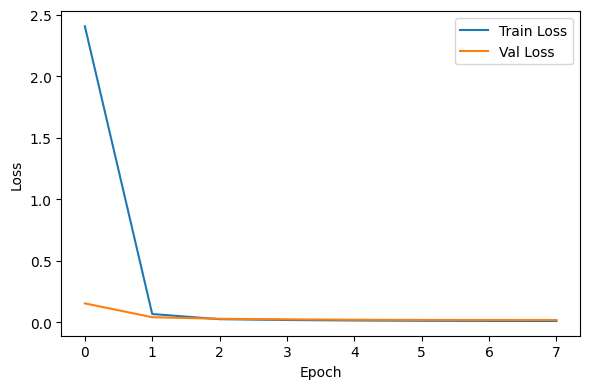

Checkpoint saved → /content/drive/MyDrive/slm_checkpoints/stage1.pt


In [11]:
EPOCHS = 8
collate = partial(collate_fn, pad_id=pad_id)

train_ds = TextDataset(fw_train, tok, max_length=MAX_LEN)
val_ds   = TextDataset(fw_val,   tok, max_length=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

total_steps = (len(train_loader) // ACCUM) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
print(f'Stage 1 | steps={total_steps} | eff-batch={BATCH * ACCUM}')

model = train_model(model, train_loader, val_loader, optimizer, device,
                    epochs=EPOCHS, scheduler=scheduler, accumulation_steps=ACCUM)

torch.save({'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(),
            'config': dict(vocab_size=vocab_size, dim=DIM, depth=DEPTH, heads=HEADS,
                           mlp_dim=MLP_DIM, window=WINDOW)},
           f'{CKPT_DIR}/stage1.pt')
print(f'Checkpoint saved → {CKPT_DIR}/stage1.pt')

## Stage 2 — Pre-train on Cosmopedia-v2

Synthetic textbook-quality content across 34K+ topics.  
**Phi-1 key insight**: textbook-style data disproportionately improves reasoning at small scale.  
Stream 20K examples.

In [13]:
print('Streaming Cosmopedia-v2 (20K examples)...')
cosmo_stream = load_dataset('HuggingFaceTB/cosmopedia-v2', name='cosmopedia-v2', split='train', streaming=True)
cosmo_list   = list(cosmo_stream.take(20_000))
cosmo_train  = cosmo_list[:18_000]
cosmo_val    = cosmo_list[18_000:]
print(f'Cosmopedia-v2 — train: {len(cosmo_train):,}  |  val: {len(cosmo_val):,}')

Streaming Cosmopedia-v2 (20K examples)...


Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Cosmopedia-v2 — train: 18,000  |  val: 2,000


Stage 2 | steps=3372 | eff-batch=32
started Training...
Epoch 1/6 - Train Loss: 0.0199, Val Loss: 0.0102, Acc: 99.94%
Epoch 2/6 - Train Loss: 0.0134, Val Loss: 0.0119, Acc: 99.93%
Epoch 3/6 - Train Loss: 0.0138, Val Loss: 0.0152, Acc: 99.89%
Epoch 4/6 - Train Loss: 0.0137, Val Loss: 0.0160, Acc: 99.88%
Epoch 5/6 - Train Loss: 0.0131, Val Loss: 0.0162, Acc: 99.87%
Epoch 6/6 - Train Loss: 0.0126, Val Loss: 0.0162, Acc: 99.87%


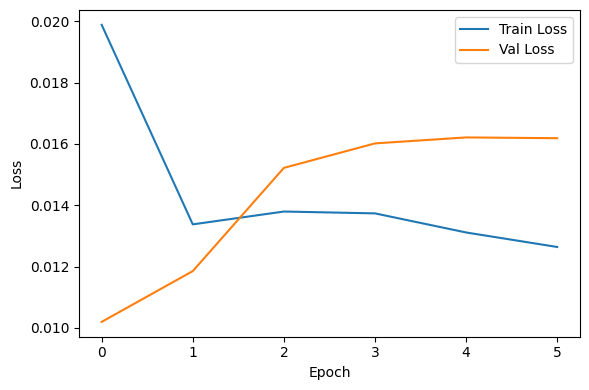

Checkpoint saved → /content/drive/MyDrive/slm_checkpoints/stage2.pt


In [14]:
EPOCHS = 6
train_ds = TextDataset(cosmo_train, tok, max_length=MAX_LEN)
val_ds   = TextDataset(cosmo_val,   tok, max_length=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

total_steps = (len(train_loader) // ACCUM) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
print(f'Stage 2 | steps={total_steps} | eff-batch={BATCH * ACCUM}')

model = train_model(model, train_loader, val_loader, optimizer, device,
                    epochs=EPOCHS, scheduler=scheduler, accumulation_steps=ACCUM)

torch.save({'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(),
            'config': dict(vocab_size=vocab_size, dim=DIM, depth=DEPTH, heads=HEADS,
                           mlp_dim=MLP_DIM, window=WINDOW)},
           f'{CKPT_DIR}/stage2.pt')
print(f'Checkpoint saved → {CKPT_DIR}/stage2.pt')

Loading TinyStories...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

TinyStories — train: 20,000  |  val: 1,000
Stage 3 | steps=3125 | eff-batch=32
started Training...
Epoch 1/5 - Train Loss: 0.0103, Val Loss: 0.0037, Acc: 99.96%
Epoch 2/5 - Train Loss: 0.0024, Val Loss: 0.0043, Acc: 99.97%
Epoch 3/5 - Train Loss: 0.0016, Val Loss: 0.0053, Acc: 99.97%
Epoch 4/5 - Train Loss: 0.0012, Val Loss: 0.0058, Acc: 99.96%
Epoch 5/5 - Train Loss: 0.0010, Val Loss: 0.0059, Acc: 99.96%


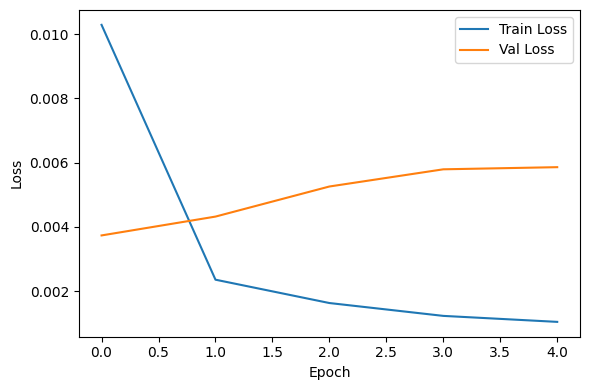

Checkpoint saved → /content/drive/MyDrive/slm_checkpoints/stage3.pt


In [15]:
# ── Stage 3 — TinyStories (narrative coherence) ──────────────────────────────
print('Loading TinyStories...')
ts_train = load_dataset('roneneldan/TinyStories', split='train').select(range(20_000))
ts_val   = load_dataset('roneneldan/TinyStories', split='validation').select(range(1_000))
print(f'TinyStories — train: {len(ts_train):,}  |  val: {len(ts_val):,}')

EPOCHS = 5
train_ds = TextDataset(ts_train, tok, max_length=MAX_LEN)
val_ds   = TextDataset(ts_val,   tok, max_length=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

total_steps = (len(train_loader) // ACCUM) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
print(f'Stage 3 | steps={total_steps} | eff-batch={BATCH * ACCUM}')

model = train_model(model, train_loader, val_loader, optimizer, device,
                    epochs=EPOCHS, scheduler=scheduler, accumulation_steps=ACCUM)

torch.save({'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(),
            'config': dict(vocab_size=vocab_size, dim=DIM, depth=DEPTH, heads=HEADS,
                           mlp_dim=MLP_DIM, window=WINDOW)},
           f'{CKPT_DIR}/stage3.pt')
print(f'Checkpoint saved → {CKPT_DIR}/stage3.pt')

In [16]:
# ── Switch to fine-tuning mode ───────────────────────────────────────────────
# Pre-training used dropout=0.0 (full capacity).
# Fine-tuning on small datasets needs dropout to prevent overfitting.
base_model = getattr(model, '_orig_mod', model)  # unwrap torch.compile if needed
base_model.set_dropout(0.15)

LR = 1e-4  # lower LR for fine-tuning
optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=0.1, betas=(0.9, 0.95))
print('Fine-tuning mode: dropout=0.15, LR=1e-4')

Fine-tuning mode: dropout=0.15, LR=1e-4


## Stage 4 — Fine-tune on Dolly-15k

15K human-authored instruction/response pairs — zero GPT-4 contamination.  
Keep to **3 epochs** to avoid forgetting pre-training knowledge.  
Dropout is now enabled (set in the cell above).

In [17]:
dolly_full = load_dataset('databricks/databricks-dolly-15k', split='train')

def dolly_to_alpaca(ex):
    return {'instruction': ex['instruction'],
            'input':       ex.get('context', ''),
            'output':      ex['response']}
dolly_full = dolly_full.map(dolly_to_alpaca)

n = len(dolly_full)
dolly_train = dolly_full.select(range(int(n * 0.9)))
dolly_val   = dolly_full.select(range(int(n * 0.9), n))
print(f'Dolly-15k — train: {len(dolly_train):,}  |  val: {len(dolly_val):,}')

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Map:   0%|          | 0/15011 [00:00<?, ? examples/s]

Dolly-15k — train: 13,509  |  val: 1,502


Stage 4 | steps=2110 | eff-batch=32
started Training...
Epoch 1/5 - Train Loss: 1.1041, Val Loss: 0.4085, Acc: 97.74%
Epoch 2/5 - Train Loss: 0.4270, Val Loss: 0.2787, Acc: 98.19%
Epoch 3/5 - Train Loss: 0.3084, Val Loss: 0.2452, Acc: 98.11%
Epoch 4/5 - Train Loss: 0.2678, Val Loss: 0.2348, Acc: 98.20%
Epoch 5/5 - Train Loss: 0.2553, Val Loss: 0.2341, Acc: 98.17%


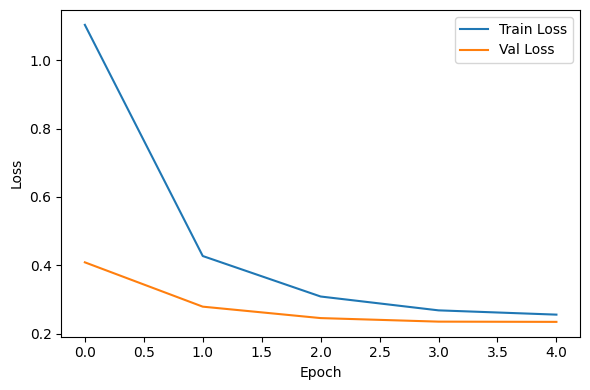

Checkpoint saved → /content/drive/MyDrive/slm_checkpoints/stage4.pt


In [18]:
EPOCHS = 5
train_ds = InstructDataset(dolly_train, tok, max_length=MAX_LEN)
val_ds   = InstructDataset(dolly_val,   tok, max_length=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

total_steps = (len(train_loader) // ACCUM) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
print(f'Stage 4 | steps={total_steps} | eff-batch={BATCH * ACCUM}')

model = train_model(model, train_loader, val_loader, optimizer, device,
                    epochs=EPOCHS, scheduler=scheduler, accumulation_steps=ACCUM)

torch.save({'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(),
            'config': dict(vocab_size=vocab_size, dim=DIM, depth=DEPTH, heads=HEADS,
                           mlp_dim=MLP_DIM, window=WINDOW)},
           f'{CKPT_DIR}/stage4.pt')
print(f'Checkpoint saved → {CKPT_DIR}/stage4.pt')

Loading Open-Platypus...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-4fe2df04669d16(…):   0%|          | 0.00/15.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24926 [00:00<?, ? examples/s]

Map:   0%|          | 0/24926 [00:00<?, ? examples/s]

Open-Platypus — train: 22,433  |  val: 2,493
Stage 5 | steps=3505 | eff-batch=32
started Training...
Epoch 1/5 - Train Loss: 0.1454, Val Loss: 0.1823, Acc: 98.39%
Epoch 2/5 - Train Loss: 0.0871, Val Loss: 0.2242, Acc: 97.52%
Epoch 3/5 - Train Loss: 0.0807, Val Loss: 0.2378, Acc: 97.38%
Epoch 4/5 - Train Loss: 0.0779, Val Loss: 0.2569, Acc: 97.20%
Epoch 5/5 - Train Loss: 0.0762, Val Loss: 0.2555, Acc: 97.24%


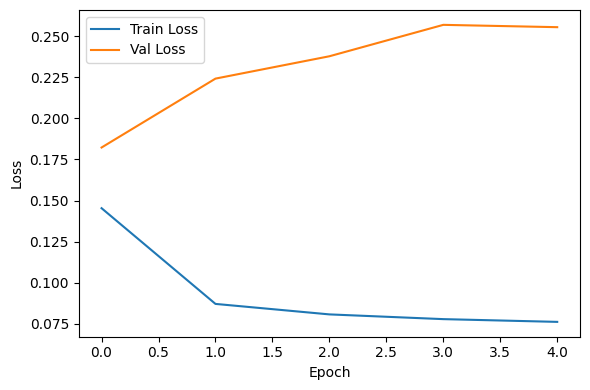

Checkpoint saved → /content/drive/MyDrive/slm_checkpoints/stage5.pt


In [19]:
# ── Stage 5 — Fine-tune on Open-Platypus (STEM / reasoning) ─────────────────
print('Loading Open-Platypus...')
platypus = load_dataset('garage-bAInd/Open-Platypus', split='train')

def platypus_to_alpaca(ex):
    return {'instruction': ex['instruction'],
            'input':       ex.get('input', ''),
            'output':      ex['output']}
platypus = platypus.map(platypus_to_alpaca)

n = len(platypus)
plat_train = platypus.select(range(int(n * 0.9)))
plat_val   = platypus.select(range(int(n * 0.9), n))
print(f'Open-Platypus — train: {len(plat_train):,}  |  val: {len(plat_val):,}')

EPOCHS = 5
train_ds = InstructDataset(plat_train, tok, max_length=MAX_LEN)
val_ds   = InstructDataset(plat_val,   tok, max_length=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

total_steps = (len(train_loader) // ACCUM) * EPOCHS
scheduler   = get_cosine_schedule_with_warmup(optimizer, total_steps // 10, total_steps)
print(f'Stage 5 | steps={total_steps} | eff-batch={BATCH * ACCUM}')

model = train_model(model, train_loader, val_loader, optimizer, device,
                    epochs=EPOCHS, scheduler=scheduler, accumulation_steps=ACCUM)

torch.save({'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(),
            'config': dict(vocab_size=vocab_size, dim=DIM, depth=DEPTH, heads=HEADS,
                           mlp_dim=MLP_DIM, window=WINDOW)},
           f'{CKPT_DIR}/stage5.pt')
print(f'Checkpoint saved → {CKPT_DIR}/stage5.pt')

## Generate text

In [ ]:
import torch.nn.functional as F

# Tokens that should never appear in generated output
SUPPRESS = [tok.pad_token_id]
if tok.unk_token_id is not None:
    SUPPRESS.append(tok.unk_token_id)

def _banned_ngram_tokens(input_ids: torch.Tensor, ngram_size: int) -> list[int]:
    """Return tokens that would create a repeated n-gram at the current position."""
    n = input_ids.shape[0]
    if n < ngram_size - 1:
        return []
    tail = input_ids[-(ngram_size - 1):].tolist()
    banned = set()
    for i in range(n - ngram_size + 1):
        if input_ids[i : i + ngram_size - 1].tolist() == tail:
            banned.add(input_ids[i + ngram_size - 1].item())
    # The loop above searches positions 0..n-2 for the tail prefix.
    # When a token first appears (only at position n-1), the loop finds nothing
    # and A→A repetition slips through.  Always ban the last token itself.
    if ngram_size >= 2:
        banned.add(input_ids[-1].item())
    return list(banned)

@torch.inference_mode()
def generate(prompt: str, max_new_tokens: int = 100,
             temperature: float = 0.9, top_k: int = 50,
             repetition_penalty: float = 1.5,
             no_repeat_ngram_size: int = 3) -> str:
    model.eval()
    ids = tok.encode(prompt)
    if ids and ids[-1] == eos_id:
        ids = ids[:-1]
    prompt_len = len(ids)
    x = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):
        logits = model(x)[:, -1, :]  # [1, V]

        # Repetition penalty on all tokens seen so far
        if repetition_penalty != 1.0:
            seen = x[0].unique()
            score = logits[0, seen]
            logits[0, seen] = torch.where(score > 0,
                                          score / repetition_penalty,
                                          score * repetition_penalty)

        # Hard-ban any token that would repeat an n-gram
        if no_repeat_ngram_size > 1:
            for banned_id in _banned_ngram_tokens(x[0], no_repeat_ngram_size):
                logits[0, banned_id] = float('-inf')

        # Suppress special tokens
        for sid in SUPPRESS:
            logits[:, sid] = float('-inf')

        if temperature == 0:
            next_token = logits.argmax(dim=-1, keepdim=True)
        else:
            logits = logits / temperature
            if top_k > 0:
                k = min(top_k, logits.size(-1))
                threshold = logits.topk(k).values[:, -1, None]
                logits = logits.masked_fill(logits < threshold, float('-inf'))
            next_token = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1)

        x = torch.cat([x, next_token], dim=1)
        if next_token.item() == eos_id:
            break

    return tok.decode(x[0, prompt_len:].tolist(), skip_special_tokens=True)

print('=== Factual ===')
print(generate('The capital of France is'))

print('\n=== Story ===')
print(generate('Once upon a time there was a little'))

print('\n=== Instruction ===')
print(generate('### Instruction:\nExplain what a neural network is.\n\n### Response:\n'))

## Post-Training Behavior Checks

Run after all training stages to confirm the model learned and nothing broke.

| Check | What it catches |
|---|---|
| Loss finite | NaN loss from gradient explosion |
| Loss < log(V) | Model failed to beat the random baseline |
| Perplexity | Human-readable learning signal |
| Top-1 accuracy | Complete prediction failure |
| Logits finite | NaN/Inf introduced during training |
| Embedding finite | Weight corruption (gradient explosion) |
| Causal mask intact | Structural damage during training |
| Tokens in vocab | Out-of-bounds generation (broken `resize_embeddings`) |
| Per-sample breakdown | Identifies which sentence types the model struggles with |
| Loss vs baseline | Quantifies how much was learned vs random init |

In [ ]:
from tests.test_training import check_trained_model
check_trained_model(model, tok, device, vocab_size, pad_id)

## Save checkpoint

Download both files before your session ends:  
- `/content/models/slm_checkpoint.pt`  
- `/content/tokenizer.pkl.gz`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/slm_checkpoints'
os.makedirs(DRIVE_DIR, exist_ok=True)

torch.save({
    'model_state':     model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'config': dict(
        vocab_size=vocab_size,
        dim=DIM, depth=DEPTH, heads=HEADS,
        mlp_dim=MLP_DIM, window=WINDOW,
        dropout=DROPOUT,
    ),
}, f'{DRIVE_DIR}/slm_checkpoint.pt')

print(f'Saved to {DRIVE_DIR}/slm_checkpoint.pt')

## Resume from checkpoint (new session)

In [ ]:
# Upload both slm_checkpoint.pt and tokenizer.pkl.gz, then run this cell
ckpt = torch.load('/content/models/slm_checkpoint.pt', map_location=device)
cfg  = ckpt['config']

from transformers import AutoTokenizer
HF_MODEL_NAME = 'bert-base-uncased'
tok = AutoTokenizer.from_pretrained(HF_MODEL_NAME)
pad_id     = tok.pad_token_id
eos_id     = tok.eos_token_id
vocab_size = tok.vocab_size

# Restore hyperparams from checkpoint
DIM     = cfg['dim']
DEPTH   = cfg['depth']
HEADS   = cfg['heads']
MLP_DIM = cfg['mlp_dim']
WINDOW  = cfg['window']
DROPOUT = cfg.get('dropout', 0.1)
MAX_LEN = WINDOW
LR      = 3e-4

model = Transformer(
    vocab_size=cfg['vocab_size'],
    dim=DIM, depth=DEPTH, heads=HEADS,
    mlp_dim=MLP_DIM, window=WINDOW,
    dropout=DROPOUT, tie_weights=True,
    use_checkpoint=True,
).to(device)
model.load_state_dict(ckpt['model_state'])

optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=0.01, betas=(0.9, 0.95))
optimizer.load_state_dict(ckpt['optimizer_state'])

collate = partial(collate_fn, pad_id=pad_id)
SUPPRESS = [tok.pad_token_id]
if tok.unk_token_id is not None:
    SUPPRESS.append(tok.unk_token_id)

print('Resumed from checkpoint')